In [1]:
import copy
import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
from functools import partial
from scipy.optimize import NonlinearConstraint, Bounds, minimize, approx_fprime

from IPython import display

import otaf
from gldpy import GLD

In [2]:
Dext = 20 ## Diameter of holes in mm
Dint = 19.8 ## Diameter of pins in mm
EH = 50 ## Distance between the hole axises
LB = 25 # Distance between border holes axis and edge.
hPlate = 30 #Height of the plates in mm
hPin = 60 #Height of the pins in mm

CIRCLE_RESOLUTION = 64 # NUmber of points to model the contour of the outer holes

l0, l1, l2, l3 = sp.symbols('l0 l1 l2 l3')
length_subs = {l0: EH, l1: EH, l2:hPlate, l3:hPlate}

In [3]:
defect_vars = otaf.example_models.models_3_D.defect_vars
clearance_vars = otaf.example_models.models_3_D.clearance_vars

In [4]:
def sigma_delta_circular_feature(theta, sr, su, sv):
    """This function is used to obtain the standard deviation of the defect for a point in the circular features 
    This can also be used as a basis for a constraint function (to always have the same max standard deviation over the circular feature)
    """
    return np.sqrt(sr**2 + np.cos(theta)**2 * su**2 + np.sin(theta)**2 * sv**2)

def sigma_delta_3D_plane(x,y, sw, sa, sb):
    """This function is used to obtain the standard deviation of the defect for a point on the plane feature 
    This can also be used as a basis for a constraint function
    """
    return np.sqrt(sw**2 + y**2 * sa**2 + x**2 * sb**2)

def sigma_delta_cylindrical_feature(z, theta, sr, su, salpha, sv, sbeta):
    return np.sqrt(sr**2 + (su**2+(sbeta*z)**2)*np.cos(theta)**2 + (sv**2+(salpha*z)**2)*np.sin(theta)**2)

In [5]:
loop_exprs, d_vars, c_vars = otaf.example_models.models_3_D.get_kinematic_loop_expressions()
interf_exprs = otaf.example_models.models_3_D.get_interface_constraint_expressions(num_points=CIRCLE_RESOLUTION, 
                                                                                   strategy=otaf.example_models.models_3_D.LinearizationStrategy.CIRCUMSCRIBED, 
                                                                                   z_eval_points=[-hPlate/2, hPlate/2])

otaf_mapping = otaf.example_models.models_3_D.create_dynamic_mapping(defect_vars, clearance_vars)
mapped_loop_exprs = otaf.example_models.models_3_D.rename_variables(loop_exprs, otaf_mapping)
mapped_interf_exprs = otaf.example_models.models_3_D.rename_variables(interf_exprs, otaf_mapping)

In [6]:
mapped_clearances = [otaf_mapping[var] for var in clearance_vars if var in otaf_mapping]
mapped_defects = [otaf_mapping[var] for var in defect_vars if var in otaf_mapping]


comp_mats = otaf.example_models.models_3_D.extract_linear_matrices(mapped_loop_exprs, mapped_clearances, mapped_defects, [l0,l1,l2,l3], length_subs)
interf_mats = otaf.example_models.models_3_D.extract_linear_matrices(mapped_interf_exprs, mapped_clearances, mapped_defects, [l0,l1,l2,l3], length_subs)

In [7]:
# 1. Extract matrices as numpy arrays (ensure float dtype)
# The coefficient matrices must remain 2D, but the constant vectors MUST be 1D
A_eq_gap = np.array(comp_mats[0], dtype=float)
A_eq_def = np.array(comp_mats[1], dtype=float)
K_eq     = np.array(comp_mats[2], dtype=float).flatten()  # <--- Flatten to 1D

A_ub_gap = np.array(interf_mats[0], dtype=float)
A_ub_def = np.array(interf_mats[1], dtype=float)
K_ub     = np.array(interf_mats[2], dtype=float).flatten()  # <--- Flatten to 1D

# 2. Repack them in the exact order SOCAM expects: (Defect, Gap, Constant)
# We multiply the inequality matrices by -1 to convert from (<= 0) to (>= 0)
matrices_for_socam = [
    A_eq_def, 
    A_eq_gap, 
    K_eq,
    -A_ub_def,  
    -A_ub_gap,  
    -K_ub       
]

SOCAM =otaf.SystemOfConstraintsAssemblyModel(matrices=matrices_for_socam)
SOCAM.deviation_symbols = copy.deepcopy(mapped_defects)
SOCAM.gap_symbols = copy.deepcopy(mapped_clearances)
SOCAM.embedOptimizationVariable()

In [8]:
SOCAM.test_zero_deviation_feasibility()

{'success': True,
 'status': 0,
 'message': 'Optimization terminated successfully. (HiGHS Status 7: Optimal)',
 'gap_values': array([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
        -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
        -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
        -0., -0., -0., -0., -0.]),
 'objective': 0.0}

## Reduced model
The model has originally 50 variables. We'll make some adaptations to reduce the dimensions to 32:
- Fix all the diameter variables
- Suppose the defect on the contact planes to be 0

With that we'll arrive at 32 dimensions. 

First let's define the vectors of maximum standard deviations and the vector of means. 
The max standard deviations are defined such if only that one defect components acts on the feature, the capability is equal to the target.
The tolerance values are arbitrarily chosen to work with probabilities not too small to estiamte.

In [9]:
tol = 0.25 #* np.sqrt(2)
Cm = 1 # Process capability

# Defining the uncertainties on the position and orientation of the holes
sigma_e_pos = tol / (6 * Cm)
theta_max = tol / hPlate
sigma_e_theta = (2 * theta_max) / (6 * Cm)

# Defining the uncertainties on the position and orientation of the plates
sigma_e_pos_plate = tol / (6 * Cm)
sigma_e_theta_plate = (2 * (tol/(EH+LB))) / (6 * Cm)

#Defining uncertaintis on the diameters.
sigma_diam = sigma_e_pos#/2 #the defect of diamtereal defects is double, but choice is still arbitrary

In [10]:
mu_vect = np.array([0.0]*38+[Dext]*8+[Dint]*4)
std_vect = np.array([sigma_e_theta_plate, sigma_e_theta_plate, sigma_e_pos_plate]*2
                   +[sigma_e_theta, sigma_e_theta, sigma_e_pos, sigma_e_pos]*8
                   +[sigma_diam]*12)
var_mask = np.zeros((50,))
var_mask[6:38] = 1

In [11]:
# Here we have a distribution in the standard space. 
defect_distribution = otaf.distribution.get_composed_normal_defect_distribution(
    mapped_defects,
    mu_list = mu_vect.tolist(),
    sigma_list = std_vect.tolist())

### With the old implementation we didn't manage to get a neural network based surrogate model, but cause the model had errors, we'll try again

In [12]:
## NN surrogate to hopefully make things a bit faster.
# Define the seed, sample size, and file paths
SEED = 420  # Example seed value
sample_size = 200000

# Ensure reproducibility by setting the seed
np.random.seed(SEED)

# Generate the sample
dist = otaf.distribution.multiply_composed_distribution_standard_with_constants(
    defect_distribution, [1.1]*50) # We now work with low failure probabilities so we increase the dispresion to have more failed parts for the training
#TRAIN_SAMPLE = np.array(otaf.uncertainty.generateLHSExperiment(dist, sample_size))
TRAIN_SAMPLE = np.array(otaf.sampling.generate_and_transform_sequence(50,sample_size,dist),dtype="float32")
# Compute the results
TRAIN_RESULTS = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
    SOCAM,
    TRAIN_SAMPLE,
    bounds=None,
    n_cpu=-2,
    progress_bar=True,
    batch_size=500,
    dtype="float32"
)

# Assign X and y from TRAIN_SAMPLE and TRAIN_RESULTS
Xtrain = TRAIN_SAMPLE
ytrain = TRAIN_RESULTS
print(f"Ratio of failed simulations in sample : {np.where(ytrain[:,-1]<0,1,0).sum()/sample_size}")

  0%|          | 0/200000 [00:00<?, ?it/s]

Ratio of failed simulations in sample : 0.324135


In [13]:
TEST_SAMPLE = np.array(otaf.sampling.generate_and_transform_sequence(50,20000,defect_distribution),dtype="float32")
TEST_RESULTS = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
    SOCAM,
    TEST_SAMPLE,
    n_cpu=-2,
    batch_size=500,
    dtype="float32"
)
# Assign X and y from TRAIN_SAMPLE and TRAIN_RESULTS
Xtrain0 = TEST_SAMPLE
ytrain0 = TEST_RESULTS
print(f"Ratio of failed simulations in test sample : {np.where(ytrain0[:,-1]<0,1,0).sum()/20000}")

Ratio of failed simulations in test sample : 0.19335


[50, 264, 127, 39, 1]


  0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 001, Val Loss: 0.879602, Val R2: -30.863457


  0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 002, Val Loss: 0.695633, Val R2: -0.702110


...

Epoch 1498, Val Loss: 0.019150, Val R2: 0.979694


  0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 1499, Val Loss: 0.017655, Val R2: 0.981739


  0%|          | 0/4 [00:00<?, ?batch/s]

Epoch 1500, Val Loss: 0.016653, Val R2: 0.983189
Finished training at epoch 1500 with best loss 0.013525 and R2 of 0.986176


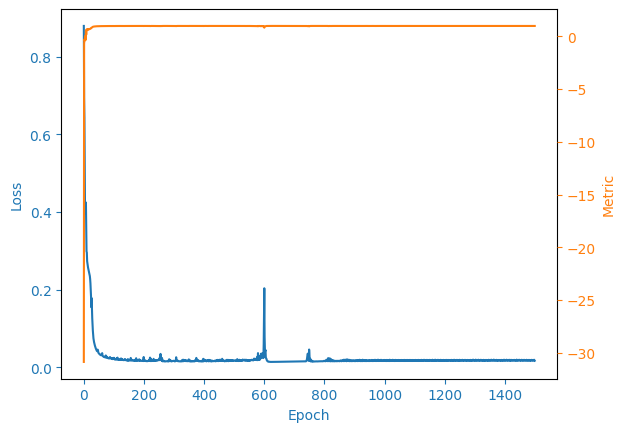

In [14]:
import torch
dim = int(defect_distribution.getDimension())
neural_model = otaf.surrogate.NeuralRegressorNetwork(
    dim, 1,
    Xtrain, ytrain[:,-1], 
    clamping=True, 
    finish_critertion_epoch=5,
    loss_finish=1e-6, 
    metric_finish=0.988, 
    max_epochs=1500, 
    batch_size=30000, 
    compile_model=False, 
    train_size=0.6, 
    input_description=defect_distribution.getDescription(),
    display_progress_disable=False)

lr=0.003

#neural_model.model = KAN([dim, 8, 4, 1])  #otaf.surrogate.get_base_relu_mlp_model(dim, 1, False)

neural_model.model = torch.nn.Sequential(
    *otaf.surrogate.get_custom_mlp_layers([dim, 500, 750, 500, 200, 50, 1], activation_class=torch.nn.GELU)
)

neural_model.optimizer = torch.optim.AdamW(neural_model.parameters(), lr=lr, weight_decay=1e-4)
otaf.surrogate.initialize_model_weights(neural_model)
neural_model.scheduler =  torch.optim.lr_scheduler.ExponentialLR(neural_model.optimizer, 1.0001)
neural_model.loss_fn = torch.nn.MSELoss()
#neural_model.loss_fn = otaf.surrogate.LimitSpaceFocusedLoss(0.0001, 2, square=True) 
#neural_model.loss_fn = otaf.surrogate.PositiveLimitSpaceFocusedLoss(0.0001, 2, 4, square=False)


neural_model.train_model()
neural_model.plot_results()

In [18]:
TEST_RESULTS = neural_model.evaluate_model_non_standard_space(TEST_SAMPLE).detach().numpy()
# Assign X and y from TRAIN_SAMPLE and TRAIN_RESULTS
Xtrain2 = TEST_SAMPLE
ytrain2 = TEST_RESULTS
print(f"Ratio of failed simulations in test sample : {np.where(ytrain2[:,-1]<0,1,0).sum()/20000}")

Ratio of failed simulations in test sample : 0.19685


In [22]:
from scipy.spatial import distance
def evaluate_error_by_distance(X_train=TEST_SAMPLE, Y_train_1=ytrain0, Y_train_2=ytrain2, mu_vect=mu_vect, use_mahalanobis=True):
# Ensure inputs are numpy arrays
    X = np.asarray(X_train)
    Y_real = np.asarray(Y_train_1)
    Y_sim = np.asarray(Y_train_2)
    mu = np.asarray(mu_vect)
    
    # Array 1: Absolute Error
    errors = np.mean(np.abs(Y_real - Y_sim), axis=1)
    
    # Array 2: Distance from mu_vect
    if use_mahalanobis:
        # Calculate covariance matrix and its inverse for Mahalanobis
        cov_matrix = np.cov(X, rowvar=False)
        inv_cov_matrix = np.linalg.inv(cov_matrix)
        distances = np.array([distance.mahalanobis(x, mu, inv_cov_matrix) for x in X])
    else:
        # Standard Euclidean distance
        distances = np.linalg.norm(X - mu, axis=1)
        
    # Sort both arrays by distance for easier plotting and analysis
    sort_idx = np.argsort(distances)
    distances_1d = distances[sort_idx]
    errors_1d = errors[sort_idx]
    
    return distances_1d, errors_1d

bc, me = evaluate_error_by_distance()
print(bc.shape)
print(me.shape)

(20000,)
(20000,)


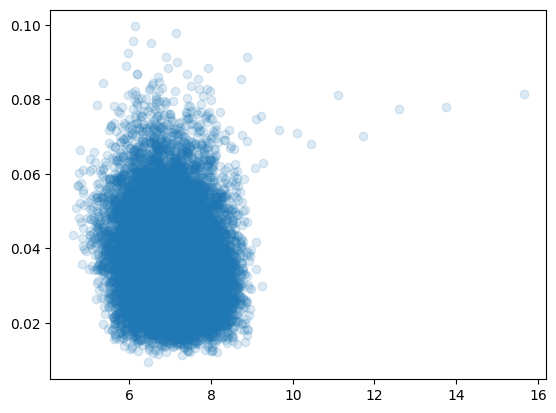

In [23]:
plt.scatter(bc, me, alpha=0.15)

## Thats good. Let's go on to imprecise tolerance analysis

In [24]:
#Function to store results

result_dict={}

def store_results(x, fp_gld, fp_slack, gld_params, experiment_key=None, result_dict=result_dict):
    x_key = otaf.common.bidirectional_string_to_array_conversion(x)
    x_dict = {"FP_GLD": fp_gld, "FP_SLACK":fp_slack, "GLD_PARAMS": gld_params}
    if experiment_key is None:
        if x_key in result_dict.keys():
            result_dict[x_key].update(x_dict)
        else :
            result_dict[x_key] = x_dict
    else : 
        if experiment_key not in result_dict:
            result_dict[experiment_key] = {}
        if x_key in result_dict[experiment_key].keys():
            result_dict[experiment_key][x_key].update(x_dict)
        else:
            result_dict[experiment_key][x_key] = x_dict

In [42]:
NDim_Defects = len(mu_vect)
SIZE_MC_PF = 100000 #int(1e6) #1e4
sample_gld = np.array(defect_distribution.getSample(SIZE_MC_PF))
scale_factor = 1.0
GLD_parameters = [] # We need the parameters of the generalized lambda distribution.

result_list = [] # Will be list of lists, where each sub list is a list of the input vector x and one for the gld paramters

# Generalized lambda distribution object for fitting
gld = GLD('VSL')

def model_base(x, sample=sample_gld):
    "x is the vector of values between 0 and 1"
    # Model without surrogate, to get slack
    x = (sample-mu_vect)*x + mu_vect
    optimization_variables = otaf.uncertainty.compute_gap_optimizations_on_sample_batch(
        constraint_matrix_generator=SOCAM,
        deviation_array=x,
        batch_size=500,
        n_cpu=-1,
        progress_bar=True,
        verbose=0,
        dtype="float32",
    )
    slack_values = optimization_variables[:,-1]
    return slack_values

def model2(x, sample=sample_gld): 
    # Surrogate ai model
    x = (sample-mu_vect)*x + mu_vect
    return np.squeeze(neural_model.evaluate_model_non_standard_space(x).detach().numpy())

@otaf.optimization.scaling(scale_factor)
def optimization_function_mini(x, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict, logprob=False):
    # Here we search the minimal probability of failure
    x_eval = np.concatenate([np.zeros(6), x, np.zeros(12)])
    slack = model(x_eval)
    gld_params = gld.fit_LMM(slack,  disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        print("GLD Parameters are NaN, returning estimated Pf")
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params, xtol=1e-6)
        fp_out = fp_gld
    print(f"Pf (mini) is {fp_out}, GLD Pf is {fp_gld}, estimated PF is {fp_slack} , log prob is {np.log(1e-16+fp_out)} ")
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)
    if logprob:
        return np.log(1e-16+fp_out)
    return fp_out

@otaf.optimization.scaling(scale_factor)
def optimization_function_maxi(x, failure_slack=0.0, model=model2, experiment_key=None, result_dict=result_dict, logprob=False):
    # Here we search the maximal probability of failure so negative output
    x_eval = np.concatenate([np.zeros(6), x, np.zeros(12)])
    slack = model(x_eval)
    gld_params = gld.fit_LMM(slack, disp_fit=False, disp_optimizer=False)
    fp_slack = np.where(slack<failure_slack,1,0).mean()
    fp_gld = np.nan
    if np.any(np.isnan(gld_params)):
        print("GLD Parameters are NaN, returning estimated Pf")
        fp_out = fp_slack
    else :
        #print("\tgld_params:", gld_params)
        fp_gld = gld.CDF_num(failure_slack, gld_params, xtol=1e-6)
        fp_out = fp_gld
    print(f"Pf (maxi) is {fp_out}, GLD Pf is {fp_gld}, estimated PF is {fp_slack}, log prob is {np.log(1e-16+fp_out)}")
    store_results(x, fp_gld, fp_slack, gld_params, experiment_key, result_dict)
    if logprob:
        return -1*np.log(1e-16+fp_out)
    return fp_out*-1

### Let's define the constraint functions modeling our credal set

We'll define all the constraint functions for all the variables
We have 14 features so 14 constraint functions to define. (2 plates, 8 holes, 4 pins)

In [43]:
# Evaluates the worst-case geometric deviation at the physical extremity of the assembly's footprint (x=120, y=50).
cons0 = lambda x: sigma_delta_3D_plane(50,50, x[2], x[0], x[1]) - sigma_e_pos_plate
cons1 = lambda x: sigma_delta_3D_plane(50,50, x[5], x[3], x[4]) - sigma_e_pos_plate

# We can do stuff like this cause there is no correlation here. 
cons2 = lambda x: np.maximum( #Part 1 hole d
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[38], x[8], x[6], x[9], x[7]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[38], x[8], x[6], x[9], x[7])
) - sigma_e_pos

cons3 = lambda x: np.maximum( #Part 1 hole e
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[39], x[16], x[14], x[17], x[15]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[39], x[16], x[14], x[17], x[15])
) - sigma_e_pos

cons4 = lambda x: np.maximum( #Part 1 hole f
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[40], x[24], x[22], x[25], x[23]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[40], x[24], x[22], x[25], x[23])
) - sigma_e_pos

cons5 = lambda x: np.maximum( #Part 1 hole g
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[41], x[32], x[30], x[33], x[31]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[41], x[32], x[30], x[33], x[31])
) - sigma_e_pos

cons6 = lambda x: np.maximum( #Part 2 hole d
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[42], x[12], x[10], x[13], x[11]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[42], x[12], x[10], x[13], x[11])
) - sigma_e_pos

cons7 = lambda x: np.maximum( #Part 2 hole e
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[43], x[20], x[18], x[21], x[19]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[43], x[20], x[18], x[21], x[19])
) - sigma_e_pos

cons8 = lambda x: np.maximum( #Part 2 hole f
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[44], x[28], x[26], x[29], x[27]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[44], x[28], x[26], x[29], x[27])
) - sigma_e_pos

cons9 = lambda x: np.maximum( #Part 2 hole g
    sigma_delta_cylindrical_feature(hPlate/2, 0,       x[45], x[36], x[34], x[37], x[35]), 
    sigma_delta_cylindrical_feature(hPlate/2, np.pi/2, x[45], x[36], x[34], x[37], x[35])
) - sigma_e_pos
# These constraints are removed below since these are simple constants
cons10 = lambda x: x[46] - sigma_diam
cons11 = lambda x: x[47] - sigma_diam
cons12 = lambda x: x[48] - sigma_diam
cons13 = lambda x: x[49] - sigma_diam

In [44]:
def evaluate_manual_constraints(x):
    """Evaluates the 14 manually defined surface constraints and returns them as a numpy array."""
    return np.array([cons0(x),cons1(x),cons2(x),cons3(x),
                     cons4(x),cons5(x),cons6(x),cons7(x),
                     cons8(x),cons9(x),cons10(x),cons11(x),
                     cons12(x),cons13(x)])
    
def eval_subset(x_sub):
    """Should be array of size 32"""
    return evaluate_manual_constraints(np.concatenate([np.zeros(6), x_sub, np.zeros(12)]))[2:10]

In [45]:
# Let's find a nice starting point. 
x0 = std_vect
bounds = Bounds(0,1)
perf_func1 = lambda x: evaluate_manual_constraints(x0*x)
perf_func2 = lambda x: eval_subset(x0[6:38]*x)


def find_feasible_x0(n_vars: int, verbose: bool = True):
    """
    Finds the point in [0, 1]^n_vars closest to x=1 (maximum process spread)
    that satisfies all surface constraints for the chosen variable space.

    Parameters
    ----------
    n_vars : int
        32  → reduced space (hole defects only,  constraints cons2–cons9)
        50  → full space    (all defect groups,   constraints cons0–cons13)
    """
    assert n_vars in (32, 50), "n_vars must be 32 or 50"

    # ── Select the right constraint function ─────────────────────────────────
    if n_vars == 32:
        constraint_fn = perf_func2          # returns shape (8,)  for cons2-9
        # Analytical warm start: sigma_e_theta*z ≈ sigma_e_pos by construction,
        # so equal contributions → safe uniform scale = 1/√2
        x_warm = np.full(n_vars, 1.0 / np.sqrt(2.0))

    else:  # 50
        constraint_fn = perf_func1           # returns shape (14,) for cons0-13
        x_warm = np.ones(n_vars)
        # -- Plate group (indices 0-5): 3 variables per plate, 2 plates
        #    cons0/1: sqrt(sw² + (50·sa)² + (50·sb)²) ≤ sigma_e_pos_plate
        #    Three equal contributions → safe scale = 1/√3
        x_warm[0:6] = 1.0 / np.sqrt(3.0)
        # -- Hole group (indices 6-37): same 1/√2 argument as the 32-dim case
        x_warm[6:38] = 1.0 / np.sqrt(2.0)
        # -- Diameter group (indices 38-49): cons10-13 are x[i] - sigma_diam ≤ 0
        #    Since perf_func evaluates std_vect * x, and std_vect[38:] = sigma_diam,
        #    any x ≤ 1 already satisfies them → stay at 1.0
        x_warm[38:50] = 1.0

    # ── Verify warm start before handing to solver ───────────────────────────
    c_warm = constraint_fn(x_warm)
    if verbose:
        print(f"[{n_vars}-dim] Warm start — max constraint value: {c_warm.max():.6f} "
              f"({'feasible ✓' if c_warm.max() <= 0 else 'infeasible, solver will correct'})")

    # ── Optimisation: closest feasible point to x = 1 ────────────────────────
    result = minimize(
        fun=lambda x: np.sum((x - 1.0) ** 2),
        jac=lambda x: 2.0 * (x - 1.0),          # exact gradient — no FD cost
        x0=x_warm,
        method="SLSQP",
        bounds=Bounds(lb=1e-7, ub=1.0, keep_feasible=True),
        constraints={
            "type": "ineq",
            "fun":  lambda x: -constraint_fn(x),                         # ≤0 → ≥0
            "jac":  lambda x: -approx_fprime(x, constraint_fn, 1e-7),
        },
        options={"ftol": 1e-10, "maxiter": 500, "disp": verbose},
    )

    x_opt = result.x
    c_opt  = constraint_fn(x_opt)

    if verbose:
        print(f"\nResult — mean: {x_opt.mean():.4f}, "
              f"min: {x_opt.min():.4f}, max: {x_opt.max():.4f}")

        if n_vars == 32:
            labels = ["P1-d","P1-e","P1-f","P1-g","P2-d","P2-e","P2-f","P2-g"]
        else:
            labels = ["Plate1","Plate2",
                      "P1-d","P1-e","P1-f","P1-g",
                      "P2-d","P2-e","P2-f","P2-g",
                      "diam-3d","diam-4e","diam-5f","diam-6g"]

        print("\nConstraint values (must all be ≤ 0):")
        for label, val in zip(labels, c_opt):
            print(f"  {label:8s}: {val:+.2e}  {'✓' if val <= 0 else '✗'}")

        print(f"\nFeasible : {(c_opt <= 0).all()}")
        if not result.success:
            print(f"Solver note: {result.message}")

    return x_opt


# ── Run both ──────────────────────────────────────────────────────────────────
x0_32 = find_feasible_x0(32)
print("\n" + "="*60 + "\n")
x0_50 = find_feasible_x0(50)

[32-dim] Warm start — max constraint value: -0.000000 (feasible ✓)
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.74516600406096
            Iterations: 1
            Function evaluations: 1
            Gradient evaluations: 1

Result — mean: 0.7071, min: 0.7071, max: 0.7071

Constraint values (must all be ≤ 0):
  P1-d    : -6.94e-18  ✓
  P1-e    : -6.94e-18  ✓
  P1-f    : -6.94e-18  ✓
  P1-g    : -6.94e-18  ✓
  P2-d    : -6.94e-18  ✓
  P2-e    : -6.94e-18  ✓
  P2-f    : -6.94e-18  ✓
  P2-g    : -6.94e-18  ✓

Feasible : True


[50-dim] Warm start — max constraint value: 0.017259 (infeasible, solver will correct)


/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Iteration limit reached    (Exit mode 9)
            Current function value: 9.127194847964173
            Iterations: 500
            Function evaluations: 3912
            Gradient evaluations: 499

Result — mean: 0.6032, min: 0.2791, max: 1.0000

Constraint values (must all be ≤ 0):
  Plate1  : +8.97e-08  ✗
  Plate2  : +5.85e-07  ✗
  P1-d    : +1.76e-07  ✗
  P1-e    : +3.31e-07  ✗
  P1-f    : +8.10e-07  ✗
  P1-g    : +3.63e-07  ✗
  P2-d    : +1.89e-07  ✗
  P2-e    : +2.33e-07  ✗
  P2-f    : +5.17e-08  ✗
  P2-g    : +1.07e-07  ✗
  diam-3d : -6.25e-17  ✓
  diam-4e : +0.00e+00  ✓
  diam-5f : +0.00e+00  ✓
  diam-6g : +0.00e+00  ✓

Feasible : False
Solver note: Iteration limit reached


In [46]:
def assembly_constraint_evaluator(x_scaled, scale_factor=1.0, result_dict=None, experiment_key=None):
    if result_dict is None:
        result_dict = {}

    # Unscale back to real physical dimensions
    x_real = x_scaled * std_vect[6:38]

    # Evaluate the aggregated manual constraints with real values
    constraint_array = eval_subset(x_real)
    
    # Caching using the scaled space (cleaner keys)
    x_key = otaf.common.bidirectional_string_to_array_conversion(x_scaled)
    data = {"CONST": constraint_array}
    
    if experiment_key is not None:
        if x_key in result_dict.get(experiment_key, {}):
            result_dict[experiment_key][x_key].update(data)
        else:
            if experiment_key not in result_dict:
                result_dict[experiment_key] = {}
            result_dict[experiment_key][x_key] = data
    else:
        if x_key in result_dict:
            result_dict[x_key].update(data)
        else:
            result_dict[x_key] = data

    return constraint_array * scale_factor

In [50]:
# Create the constraint object
nonLinearConstraint = lambda resDict, expKey: NonlinearConstraint(
    fun = lambda x: assembly_constraint_evaluator(x, 1.0, resDict, expKey),
    lb  = -1e-5,  # Lower bound slack
    ub  =  1e-5,  # Upper bound slack
    keep_feasible = True,
)

In [51]:
normalized_bounds = Bounds(1e-7, 1.0, keep_feasible=True)

def pf_min_max_optimizer(failure_slack=0.0, result_dict=result_dict, experiment_key=None, logprob=True):
    # Initial guess
    x0 = [0.7]*32 # Initial guess, we have removed the last 4 since they are constant
    print(f"\nStarting optimization sequence with failure slack :{failure_slack} \n")
    # Perform the local optimization using COBYQA directly
    res_maxi = minimize(
        optimization_function_maxi, x0,
        args=(failure_slack, model2, experiment_key, result_dict,logprob),
        method="COBYQA", 
        jac=None, 
        bounds=normalized_bounds,
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -np.inf if logprob else -1.01, 
            "maxiter": 2000,
            "maxfev": 1000,
            "feasibility_tol": 1e-5,
            "initial_tr_radius": np.sqrt(32)/2,  # Scaled up slightly for the [0, 1] space
            "final_tr_radius": 0.001,
            "disp": False,
            "scale": False
        }
    )
    print('\nMaximization result:\n', res_maxi, '\n')
    
    # Perform the local optimization using COBYQA directly
    res_mini = minimize(
        optimization_function_mini, x0, 
        args=(failure_slack, model2, experiment_key, result_dict,True),
        method="COBYQA", 
        jac=None, 
        bounds=normalized_bounds,
        constraints = nonLinearConstraint(result_dict, experiment_key),
        options={
            "f_target": -np.inf if logprob else -0.01,
            "maxiter": 2500,
            "maxfev": 2500,
            "feasibility_tol": 1e-5,
            "initial_tr_radius": np.sqrt(32)/2,  # Scaled up slightly for the [0, 1] space
            "final_tr_radius": 0.001,
            "disp": False,
            "scale": False
        }
    )

    print("\nMinimization result:\n", res_mini, '\n')

    # Get gld params and fp.
    
    s_x_min = otaf.common.bidirectional_string_to_array_conversion(res_mini.x)
    s_x_max = otaf.common.bidirectional_string_to_array_conversion(res_maxi.x)
    
    if experiment_key :
        gld_min = result_dict[experiment_key][s_x_min]['GLD_PARAMS']
        gld_max = result_dict[experiment_key][s_x_max]['GLD_PARAMS']
        fp_min = result_dict[experiment_key][s_x_min]['FP_GLD']
        fp_max = result_dict[experiment_key][s_x_max]['FP_GLD']
    else :
        gld_min = result_dict[s_x_min]['GLD_PARAMS']
        gld_max = result_dict[s_x_max]['GLD_PARAMS']
        fp_min = result_dict[s_x_min]['FP_GLD']
        fp_max = result_dict[s_x_max]['FP_GLD']

    return (res_mini.x, res_maxi.x), (gld_min, gld_max), (fp_min, fp_max)

In [52]:
res_x_000, res_gld_000, res_fp_000 = pf_min_max_optimizer(0.0, result_dict, "experiment_slack00", True)
res_x_001, res_gld_001, res_fp_001 = pf_min_max_optimizer(0.01, result_dict, "experiment_slack001", True)
res_x_005, res_gld_005, res_fp_005 = pf_min_max_optimizer(0.05, result_dict, "experiment_slack005", True)

Starting optimization sequence with failure slack :0.0 

Pf (maxi) is [0.], GLD Pf is [0.], estimated PF is 0.0, log prob is [-36.84136149]


/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]
/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in scalar power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]


Pf (maxi) is [3.75815307e-05], GLD Pf is [3.75815307e-05], estimated PF is 3e-05, log prob is [-10.18899783]


/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]
/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in scalar power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]


Pf (maxi) is [5.48866592e-05], GLD Pf is [5.48866592e-05], estimated PF is 3e-05, log prob is [-9.81024024]
Pf (maxi) is [0.], GLD Pf is [0.], estimated PF is 0.0, log prob is [-36.84136149]
Pf (maxi) is [0.], GLD Pf is [0.], estimated PF is 0.0, log prob is [-36.84136149]


...

/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]
/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in scalar power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]


Pf (mini) is [0.00413064], GLD Pf is [0.00413064], estimated PF is 0.00555 , log prob is [-5.48932331] 


/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]
/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in scalar power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]


Pf (mini) is [0.00413065], GLD Pf is [0.00413065], estimated PF is 0.00555 , log prob is [-5.48932154] 
Pf (mini) is [0.0041263], GLD Pf is [0.0041263], estimated PF is 0.00555 , log prob is [-5.49037515] 
Minimization result:
  message: The maximum number of function evaluations has been exceeded
 success: False
  status: 5
     fun: -5.490853803546138
       x: [ 1.352e-02  8.284e-03 ...  9.978e-01  5.831e-03]
     nit: 564
   maxcv: 8.929344147600168e-06
    nfev: 1000


/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]
/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in scalar power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]


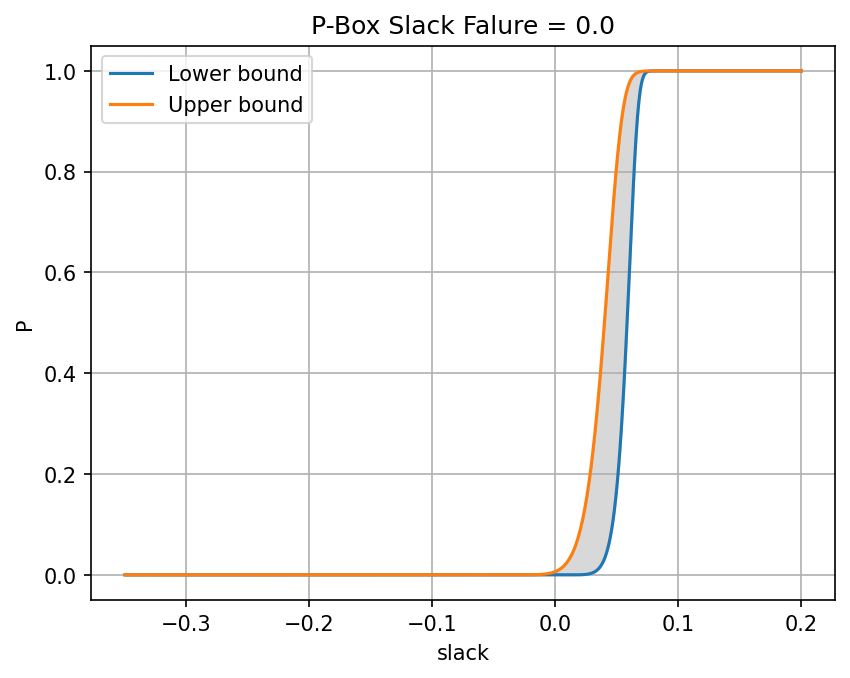

In [53]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_000, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.0")

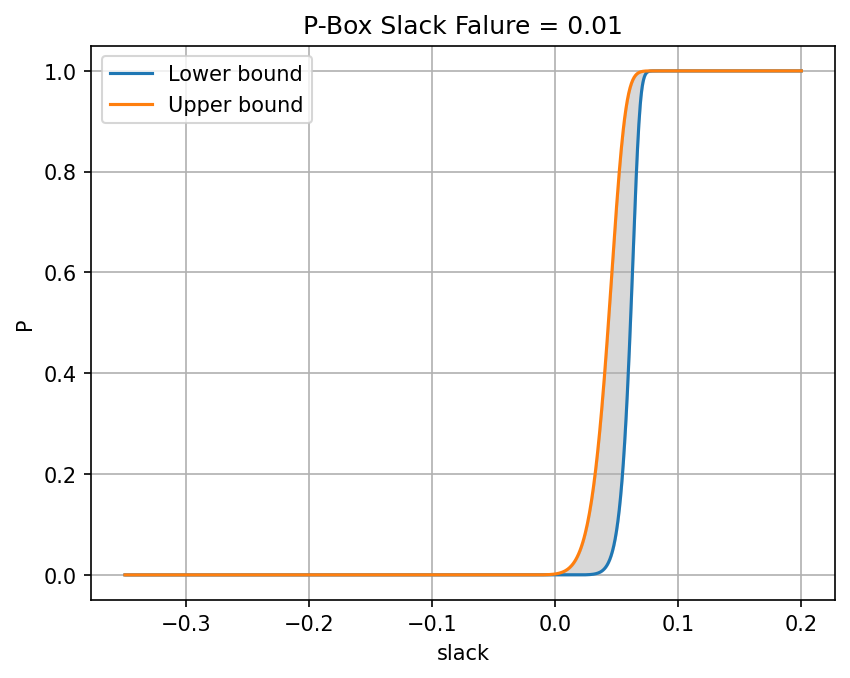

In [54]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_001, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.01")

/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]
/home/kramer84/anaconda3/envs/otaf_env/lib/python3.12/site-packages/gldpy/_gld_module.py:166: RuntimeWarning: divide by zero encountered in scalar power
  return param[0] + ((1 - param[2])*(y**param[3] - 1)/param[3] - param[2]*((1-y)**param[3] - 1)/param[3])*param[1]


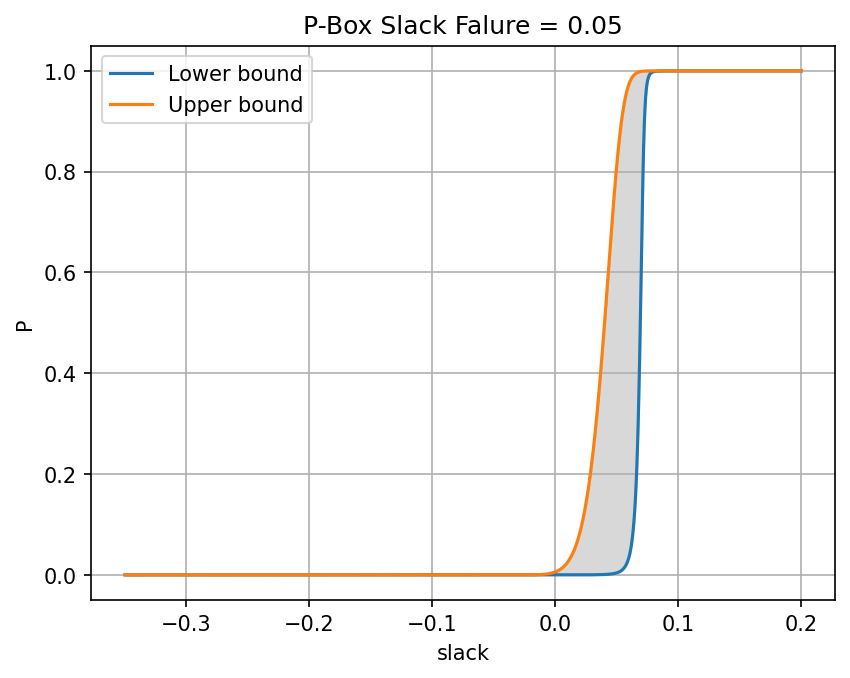

In [55]:
otaf.plotting.plot_gld_pbox_cdf(gld, *res_gld_005, np.linspace(-0.35,0.2,1000), xlabel="slack", title="P-Box Slack Falure = 0.05")